# Δεύτερο Dataset: MS COCO για Έλεγχο Γενίκευσης

Το notebook αυτό αποτελεί συμπληρωματικό μέρος της εργασίας CNN + Transformer.  
Στο κύριο notebook το μοντέλο εκπαιδεύεται και αξιολογείται στο Flickr8k. Εδώ χρησιμοποιείται το MS COCO ως δεύτερο, πιο πλούσιο dataset, ώστε να εξεταστεί αν η ίδια αρχιτεκτονική μπορεί να γενικεύσει σε περισσότερα αντικείμενα, σκηνές και περιβάλλοντα.

Ο στόχος αυτού του μέρους δεν είναι να αντικαταστήσει το Flickr8k πείραμα, αλλά να δείξει:
- μεταφορά της ίδιας αρχιτεκτονικής σε νέο dataset,
- μελέτη dataset bias,
- fine-tuning του CNN Encoder,
- ποιοτική αξιολόγηση σε εικόνες εκτός του αρχικού training subset.


## Σημείωση αναπαραγωγιμότητας

Το notebook αυτό είναι συμπληρωματικό στο βασικό Flickr8k notebook.  
Χρησιμοποιείται για cross-dataset validation στο MS COCO, δυναμικό fine-tuning και πρόσθετη αξιολόγηση Greedy vs Beam Search στα Βήματα 16-17.

Τα Βήματα 16-17 δεν κάνουν νέα εκπαίδευση: συγκρίνουν διαφορετικές στρατηγικές αποκωδικοποίησης στο ίδιο fine-tuned μοντέλο.


In [ ]:
import os
import json
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Dataset
from PIL import Image
from google.colab import drive

# 1. Σύνδεση με το Google Drive
drive.mount('/content/drive')

# 2. Κατέβασμα του MS COCO (Val 2014 & Annotations)
print("\n Κατέβασμα Εικόνων MS COCO...")
!wget -q http://images.cocodataset.org/zips/val2014.zip
!unzip -q val2014.zip -d /content/coco_images/
!rm val2014.zip

print(" Κατέβασμα Λεζαντών MS COCO...")
!wget -q http://images.cocodataset.org/annotations/annotations_trainval2014.zip
!unzip -q annotations_trainval2014.zip -d /content/coco_annotations/
!rm annotations_trainval2014.zip

# 3. Διάβασμα του JSON και δημιουργία λίστας
annotation_file = '/content/coco_annotations/annotations/captions_val2014.json'
with open(annotation_file, 'r') as f:
    coco_data = json.load(f)

images_dict = {img['id']: img['file_name'] for img in coco_data['images']}

coco_captions = []
for ann in coco_data['annotations']:
    img_id = ann['image_id']
    caption = ann['caption']
    file_name = images_dict[img_id]
    coco_captions.append((file_name, caption))

# Κρατάμε ένα δείγμα 15.000 εικόνων για γρήγορη εκπαίδευση
coco_captions = coco_captions[:15000]
print(f"\nΈτοιμο! Φορτώθηκαν {len(coco_captions)} ζευγάρια (Εικόνα - Λεζάντα).")

Mounted at /content/drive

 Κατέβασμα Εικόνων MS COCO...
 Κατέβασμα Λεζαντών MS COCO...

Έτοιμο! Φορτώθηκαν 15000 ζευγάρια (Εικόνα - Λεζάντα).


# Βήμα 1: Προετοιμασία MS COCO, Vocabulary και DataLoader

Σε αυτό το βήμα γίνεται η σύνδεση με το dataset MS COCO, η ανάγνωση των annotations, η δημιουργία λεξιλογίου και η κατασκευή του DataLoader.  
Η διαδικασία είναι αντίστοιχη με το Flickr8k notebook, αλλά εφαρμόζεται σε μεγαλύτερο και πιο ποικίλο dataset.


In [ ]:
# 1. Η κλάση του Λεξιλογίου
class Vocabulary:
    def __init__(self, freq_threshold):
        self.itos = {0: "<PAD>", 1: "<SOS>", 2: "<EOS>", 3: "<UNK>"}
        self.stoi = {"<PAD>": 0, "<SOS>": 1, "<EOS>": 2, "<UNK>": 3}
        self.freq_threshold = freq_threshold

    def __len__(self):
        return len(self.itos)

    def build_vocabulary(self, sentence_list):
        frequencies = {}
        idx = 4
        for sentence in sentence_list:
            for word in sentence.lower().split():
                if word not in frequencies:
                    frequencies[word] = 1
                else:
                    frequencies[word] += 1

                if frequencies[word] == self.freq_threshold:
                    self.stoi[word] = idx
                    self.itos[idx] = word
                    idx += 1

    def numericalize(self, text):
        tokenized_text = text.lower().split()
        return [self.stoi[token] if token in self.stoi else self.stoi["<UNK>"] for token in tokenized_text]

# 2. Φτιάχνουμε το Λεξιλόγιο από το COCO
print("Χτίσιμο του λεξιλογίου COCO...")
vocab = Vocabulary(freq_threshold=5)
all_sentences = [caption for _, caption in coco_captions]
vocab.build_vocabulary(all_sentences)
print(f"Το λεξιλόγιο έχει {len(vocab)} λέξεις!")

# 3. Ορισμός PyTorch Dataset
class COCODataset(Dataset):
    def __init__(self, captions_list, img_dir, vocab, transform=None):
        self.captions_list = captions_list
        self.img_dir = img_dir
        self.vocab = vocab
        self.transform = transform

    def __len__(self):
        return len(self.captions_list)

    def __getitem__(self, index):
        file_name, caption = self.captions_list[index]
        img_path = os.path.join(self.img_dir, file_name)
        img = Image.open(img_path).convert("RGB")

        if self.transform is not None:
            img = self.transform(img)

        numericalized_caption = [self.vocab.stoi["<SOS>"]]
        numericalized_caption += self.vocab.numericalize(caption)
        numericalized_caption.append(self.vocab.stoi["<EOS>"])

        return img, torch.tensor(numericalized_caption)

class MyCollate:
    def __init__(self, pad_idx):
        self.pad_idx = pad_idx

    def __call__(self, batch):
        imgs = [item[0].unsqueeze(0) for item in batch]
        imgs = torch.cat(imgs, dim=0)
        targets = [item[1] for item in batch]
        targets = torch.nn.utils.rnn.pad_sequence(targets, batch_first=False, padding_value=self.pad_idx)
        return imgs, targets

# 4. Μετασχηματισμοί και DataLoader
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

dataset = COCODataset(coco_captions, '/content/coco_images/val2014/', vocab, transform=transform)
pad_idx = vocab.stoi["<PAD>"]

dataloader = DataLoader(
    dataset=dataset,
    batch_size=32,
    shuffle=True,
    collate_fn=MyCollate(pad_idx=pad_idx)
)
print("Ο DataLoader είναι έτοιμος.")

# Βήμα 2: Αρχιτεκτονική CNN Encoder + Transformer Decoder

Διατηρείται η ίδια βασική αρχιτεκτονική:
- ResNet50 ως CNN Encoder για εξαγωγή οπτικών χαρακτηριστικών.
- Transformer Decoder για παραγωγή λεζάντας.
- Ενοποιημένο μοντέλο CNN-to-Transformer.

Με αυτόν τον τρόπο ελέγχεται αν το pipeline που αναπτύχθηκε στο Flickr8k μπορεί να εφαρμοστεί και στο MS COCO.


In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models

# 1. Ο Encoder: Χρησιμοποιεί το προεκπαιδευμένο ResNet50
class EncoderCNN(nn.Module):
    def __init__(self, embed_size, train_CNN=False):
        super(EncoderCNN, self).__init__() # <-- ΔΙΟΡΘΩΘΗΚΕ ΕΔΩ
        self.train_CNN = train_CNN
        resnet = models.resnet50(pretrained=True)
        modules = list(resnet.children())[:-2]
        self.resnet = nn.Sequential(*modules)
        self.adaptive_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.embed = nn.Linear(resnet.fc.in_features, embed_size)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.5)

    def forward(self, images):
        features = self.resnet(images)
        features = self.adaptive_pool(features)
        features = features.view(features.size(0), -1)
        features = self.embed(features)
        return self.relu(self.dropout(features))

# 2. Ο Decoder: Transformer Decoder
class DecoderTransformer(nn.Module):
    def __init__(self, embed_size, vocab_size, num_heads, num_layers, dropout):
        super(DecoderTransformer, self).__init__() # <-- ΔΙΟΡΘΩΘΗΚΕ ΕΔΩ
        self.word_embedding = nn.Embedding(vocab_size, embed_size)
        self.positional_encoding = nn.Parameter(torch.randn(1, 100, embed_size))
        decoder_layer = nn.TransformerDecoderLayer(d_model=embed_size, nhead=num_heads, batch_first=True)
        self.transformer_decoder = nn.TransformerDecoder(decoder_layer, num_layers=num_layers)
        self.fc_out = nn.Linear(embed_size, vocab_size)
        self.dropout = nn.Dropout(dropout)

    def forward(self, features, captions):
        batch_size, seq_len = captions.shape
        embeddings = self.word_embedding(captions) + self.positional_encoding[:, :seq_len, :]
        embeddings = self.dropout(embeddings)
        memory = features.unsqueeze(1)
        mask = torch.triu(torch.ones(seq_len, seq_len), diagonal=1).bool().to(captions.device)
        out = self.transformer_decoder(tgt=embeddings, memory=memory, tgt_mask=mask)
        return self.fc_out(out)

# 3. Το Ενοποιημένο Μοντέλο
class CNNtoTransformer(nn.Module):
    def __init__(self, embed_size, vocab_size, num_heads=8, num_layers=3, dropout=0.5):
        super(CNNtoTransformer, self).__init__() # <-- ΤΟ ΜΕΓΑΛΟ ΛΑΘΟΣ ΔΙΟΡΘΩΘΗΚΕ ΕΔΩ
        self.encoder = EncoderCNN(embed_size)
        self.decoder = DecoderTransformer(embed_size, vocab_size, num_heads, num_layers, dropout)

    def forward(self, images, captions):
        features = self.encoder(images)
        outputs = self.decoder(features, captions)
        return outputs

print("Η Αρχιτεκτονική φορτώθηκε ΣΩΣΤΑ! (ResNet50 + Transformer 3-layers)")

Η Αρχιτεκτονική φορτώθηκε ΣΩΣΤΑ! (ResNet50 + Transformer 3-layers)


# Βήμα 3: Αρχική Εκπαίδευση στο MS COCO

Σε αυτή τη φάση εκπαιδεύεται το μοντέλο στο MS COCO για λίγες εποχές, ώστε να προσαρμοστεί στο νέο λεξιλόγιο και στις διαφορετικές εικόνες του dataset.  
Η εκπαίδευση λειτουργεί ως αρχική cross-dataset δοκιμή της αρχιτεκτονικής.


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import time


# 1. Ρυθμίσεις Συσκευής και Μοντέλου
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
vocab_size = len(vocab)
embed_size = 256 # διάσταση embeddings

print(f"️ Αρχικοποίηση του μοντέλου για το COCO (Λεξιλόγιο: {vocab_size} λέξεις)...")
model = CNNtoTransformer(embed_size=embed_size, vocab_size=vocab_size).to(device)
criterion = nn.CrossEntropyLoss(ignore_index=vocab.stoi["<PAD>"])

num_epochs = 5
total_steps = len(dataloader)

print("\n Έναρξη εκπαίδευσης για 5 Εποχές.")

for epoch in range(num_epochs):
    start_time = time.time()

    # --- ΣΤΡΑΤΗΓΙΚΗ ΕΝΑΛΛΑΓΗΣ (Freeze -> Unfreeze) ---
    if epoch < 2:
        # ΣΤΑΔΙΟ Α: Μόνο ο Transformer μαθαίνει
        if epoch == 0:
            print("\n" + "="*50)
            print("  ΦΑΣΗ 1: ΕΚΜΑΘΗΣΗ ΛΕΞΙΛΟΓΙΟΥ (ResNet Frozen)")
            print("="*50)

        for param in model.encoder.parameters():
            param.requires_grad = False

        optimizer = optim.Adam(model.decoder.parameters(), lr=3e-4)

    else:
        # ΣΤΑΔΙΟ Β: Fine-tuning και στα δύο μέρη
        if epoch == 2:
            print("\n" + "="*50)
            print("  ΦΑΣΗ 2: FINE-TUNING (Layer 4 Unfrozen)")
            print("="*50)

        # Ξεκλειδώνουμε το Layer 4 και τα τελευταία επίπεδα
        for name, param in model.encoder.named_parameters():
            if "layer4" in name or "linear" in name or "embed" in name:
                param.requires_grad = True
            else:
                param.requires_grad = False

        # Διαφορικό Learning Rate (10^-5 για την όραση!)
        optimizer = optim.Adam([
            {"params": model.decoder.parameters(), "lr": 3e-4},
            {"params": filter(lambda p: p.requires_grad, model.encoder.parameters()), "lr": 1e-5}
        ])

    # --- ΒΡΟΧΟΣ ΕΚΠΑΙΔΕΥΣΗΣ ---
    model.train()
    epoch_loss = 0

    for idx, (imgs, captions) in enumerate(dataloader):
        imgs = imgs.to(device)
        captions = captions.to(device)

        # Διόρθωση διάστασης αν χρειάζεται
        if captions.shape[0] != imgs.shape[0]:
            captions = captions.transpose(0, 1)

        tgt = captions[:, :-1]
        trg_y = captions[:, 1:]

        # Forward pass
        outputs = model(imgs, tgt)
        loss = criterion(outputs.reshape(-1, outputs.shape[-1]), trg_y.reshape(-1))

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

        if idx % 100 == 0:
            print(f"Epoch [{epoch+1}/{num_epochs}] | Batch [{idx}/{total_steps}] | Loss: {loss.item():.4f}")

    avg_loss = epoch_loss / total_steps
    end_time = time.time()
    print(f"\n Εποχή {epoch+1} Τελείωσε | Μέσο Loss: {avg_loss:.4f} | Χρόνος: {(end_time - start_time)/60:.1f} λεπτά")

# --- ΑΠΟΘΗΚΕΥΣΗ ---
final_path = '/content/drive/MyDrive/coco_smart_model.pth'
torch.save(model.state_dict(), final_path)
print("\n" + ""*50)
print(f" Η ΕΚΠΑΙΔΕΥΣΗ ΟΛΟΚΛΗΡΩΘΗΚΕ!")
print(f" Το μοντέλο σώθηκε στο Drive: {final_path}")
print(""*50)

️ Αρχικοποίηση του μοντέλου για το COCO (Λεξιλόγιο: 1967 λέξεις)...

 Έναρξη εκπαίδευσης για 5 Εποχές.

  ΦΑΣΗ 1: ΕΚΜΑΘΗΣΗ ΛΕΞΙΛΟΓΙΟΥ (ResNet Frozen)
Epoch [1/5] | Batch [0/469] | Loss: 7.7357
Epoch [1/5] | Batch [100/469] | Loss: 4.1986
Epoch [1/5] | Batch [200/469] | Loss: 4.3971
Epoch [1/5] | Batch [300/469] | Loss: 3.7673
Epoch [1/5] | Batch [400/469] | Loss: 3.8449

 Εποχή 1 Τελείωσε | Μέσο Loss: 4.2581 | Χρόνος: 78.6 λεπτά
Epoch [2/5] | Batch [0/469] | Loss: 3.8565
Epoch [2/5] | Batch [100/469] | Loss: 3.9045
Epoch [2/5] | Batch [200/469] | Loss: 3.7155
Epoch [2/5] | Batch [300/469] | Loss: 3.5691
Epoch [2/5] | Batch [400/469] | Loss: 3.5359

 Εποχή 2 Τελείωσε | Μέσο Loss: 3.6256 | Χρόνος: 77.5 λεπτά

  ΦΑΣΗ 2: FINE-TUNING (Layer 4 Unfrozen)
Epoch [3/5] | Batch [0/469] | Loss: 3.6676
Epoch [3/5] | Batch [100/469] | Loss: 3.2738
Epoch [3/5] | Batch [200/469] | Loss: 3.4855
Epoch [3/5] | Batch [300/469] | Loss: 3.3422
Epoch [3/5] | Batch [400/469] | Loss: 2.9649

 Εποχή 3 Τελείωσε 

# Βήμα 4: Καμπύλη Εκπαίδευσης

Η καμπύλη loss χρησιμοποιείται για να ελεγχθεί αν το μοντέλο συγκλίνει ομαλά κατά την εκπαίδευση στο νέο dataset.  
Η πτώση του training loss δείχνει ότι το μοντέλο αρχίζει να προσαρμόζεται στα δεδομένα του MS COCO.


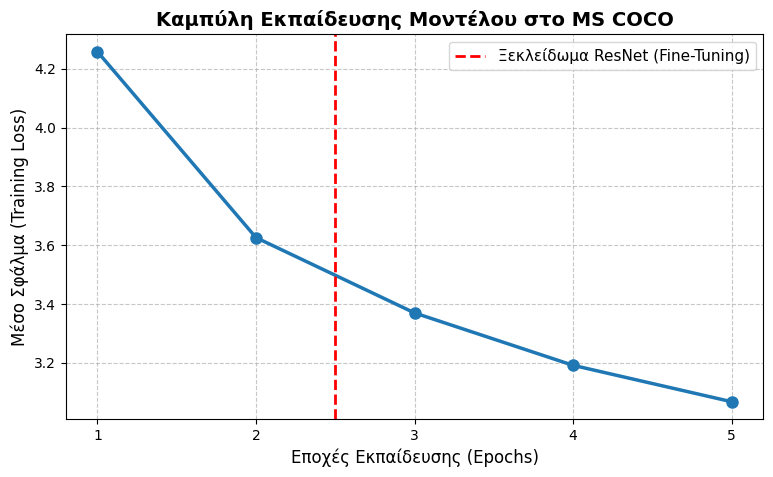

Το διάγραμμα αποθηκεύτηκε στα αρχεία του Colab ως 'training_loss_coco.png'!


In [ ]:
import matplotlib.pyplot as plt

# Τα πραγματικά δεδομένα από το log της εκπαίδευσής σου
epochs = [1, 2, 3, 4, 5]
loss_values = [4.2581, 3.6256, 3.3694, 3.1911, 3.0672]

plt.figure(figsize=(9, 5))

# Σχεδιασμός της γραμμής
plt.plot(epochs, loss_values, marker='o', linestyle='-', color='#1f77b4', linewidth=2.5, markersize=8)

# Κάθετη γραμμή για το Fine-Tuning
plt.axvline(x=2.5, color='red', linestyle='--', linewidth=2, label='Ξεκλείδωμα ResNet (Fine-Tuning)')

# Τίτλοι και μορφοποίηση
plt.title('Καμπύλη Εκπαίδευσης Μοντέλου στο MS COCO', fontsize=14, fontweight='bold')
plt.xlabel('Εποχές Εκπαίδευσης (Epochs)', fontsize=12)
plt.ylabel('Μέσο Σφάλμα (Training Loss)', fontsize=12)
plt.xticks(epochs)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=11)

# Αποθήκευση της εικόνας με υψηλή ανάλυση για το Word
plt.savefig('training_loss_coco.png', dpi=300, bbox_inches='tight')
plt.show()

print("Το διάγραμμα αποθηκεύτηκε στα αρχεία του Colab ως 'training_loss_coco.png'!")

# Βήμα 5: Ποιοτική Αξιολόγηση σε Εικόνα Εκτός Training Subset

Σε αυτό το βήμα γίνεται ποιοτική δοκιμή του μοντέλου σε εικόνα του MS COCO που δεν ανήκει στο training subset.

Η δοκιμή αυτή λειτουργεί ως γρήγορος έλεγχος γενίκευσης: συγκρίνεται η πραγματική λεζάντα του COCO με τη λεζάντα που παράγει το μοντέλο με Greedy Search.


In [ ]:
import random
import requests
import io
import torch
import matplotlib.pyplot as plt
from PIL import Image
import torchvision.transforms as transforms

# Κοινό transform για inference
inference_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])

def generate_caption_from_bytes(model, image_bytes, vocab, max_length=50):
    """
    Παράγει caption με Greedy Search από εικόνα σε μορφή bytes.
    Επιστρέφει την παραγόμενη λεζάντα και την αρχική PIL εικόνα.
    """
    model.eval()

    image = Image.open(io.BytesIO(image_bytes)).convert("RGB")
    image_tensor = inference_transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        features = model.encoder(image_tensor)
        caption_indices = [vocab.stoi["<SOS>"]]

        for _ in range(max_length):
            caption_tensor = torch.tensor(
                caption_indices,
                dtype=torch.long
            ).unsqueeze(0).to(device)

            outputs = model.decoder(features, caption_tensor)
            predicted_idx = outputs[:, -1, :].argmax(dim=-1).item()

            caption_indices.append(predicted_idx)

            if predicted_idx == vocab.stoi["<EOS>"]:
                break

    words = []
    for idx in caption_indices:
        word = vocab.itos[idx]

        if word == "<EOS>":
            break

        if word not in ["<SOS>", "<PAD>", "<UNK>"]:
            words.append(word)

    return " ".join(words), image


# Επιλογή τυχαίας εικόνας εκτός των πρώτων 15.000 annotations που χρησιμοποιήθηκαν για training
random_idx = random.randint(15001, len(coco_data["annotations"]) - 1)
sample_ann = coco_data["annotations"][random_idx]
sample_img_id = sample_ann["image_id"]
sample_img_filename = images_dict[sample_img_id]

print(f"Επιλέχθηκε εικόνα με annotation index: {random_idx}")
print(f"Ground Truth: {sample_ann['caption']}")
print("Λήψη εικόνας από τους COCO servers...")

image_url = f"http://images.cocodataset.org/val2014/{sample_img_filename}"

try:
    response = requests.get(image_url, timeout=20)
    response.raise_for_status()
    image_bytes = response.content

    predicted_caption, img = generate_caption_from_bytes(model, image_bytes, vocab)

    plt.figure(figsize=(8, 6))
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Prediction:\n{predicted_caption}", fontsize=14)
    plt.show()

    print("\n" + "=" * 50)
    print(f"Ground Truth : {sample_ann['caption']}")
    print(f"Prediction   : {predicted_caption}")
    print("=" * 50)

except Exception as e:
    print("Δεν ήταν δυνατή η λήψη ή αξιολόγηση της εικόνας.")
    print(f"Λεπτομέρειες σφάλματος: {e}")


# Βήμα 6: Ποιοτική Αξιολόγηση σε Προσωπική Εικόνα

Σε αυτό το βήμα ο χρήστης μπορεί να ανεβάσει δική του εικόνα και το μοντέλο να παράγει λεζάντα με Greedy Search.

Το κελί χρησιμοποιεί την ίδια συνάρτηση inference που ορίστηκε στο προηγούμενο βήμα.


In [ ]:
from google.colab import files
import os
import torch
import matplotlib.pyplot as plt

# Προαιρετική φόρτωση checkpoint για inference.
# Αν το αρχείο δεν υπάρχει, χρησιμοποιείται το ήδη υπάρχον model στη μνήμη.
model_path = "/content/drive/MyDrive/coco_smart_model.pth"

if os.path.exists(model_path):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    vocab_size = len(vocab)

    model = CNNtoTransformer(embed_size=256, vocab_size=vocab_size).to(device)
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()

    print("Το εκπαιδευμένο checkpoint φορτώθηκε για inference.")
else:
    print("Δεν βρέθηκε checkpoint στο Drive. Χρησιμοποιείται το υπάρχον model στη μνήμη.")

print("\nΑνέβασε μία εικόνα για ποιοτική αξιολόγηση:")
uploaded = files.upload()

if len(uploaded) > 0:
    image_name = list(uploaded.keys())[0]
    image_bytes = uploaded[image_name]

    predicted_caption, img = generate_caption_from_bytes(model, image_bytes, vocab)

    plt.figure(figsize=(8, 6))
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Prediction:\n{predicted_caption}", fontsize=14)
    plt.show()

    print("\nΠαραγόμενη λεζάντα:")
    print(predicted_caption)

    # Διαγραφή προσωρινού αρχείου από το Colab runtime
    if os.path.exists(image_name):
        os.remove(image_name)
else:
    print("Δεν ανέβηκε εικόνα για αξιολόγηση.")


# Βήμα 7: Παραγωγή Λεζάντας με Beam Search

Σε αυτό το βήμα δοκιμάζεται Beam Search ως εναλλακτική στρατηγική αποκωδικοποίησης.

Το Beam Search κρατά περισσότερες υποψήφιες ακολουθίες σε κάθε βήμα και μπορεί να παράγει πιο συνεκτικές λεζάντες σε σχέση με το Greedy Search.


In [ ]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from google.colab import files

def generate_caption_beam_search_from_bytes(model, image_bytes, vocab, beam_width=3, max_length=50):
    """
    Παράγει caption με Beam Search από εικόνα σε μορφή bytes.
    """
    model.eval()

    image = Image.open(io.BytesIO(image_bytes)).convert("RGB")
    image_tensor = inference_transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        features = model.encoder(image_tensor)

        start_token = vocab.stoi["<SOS>"]
        end_token = vocab.stoi["<EOS>"]

        beams = [(0.0, [start_token])]

        for _ in range(max_length):
            new_beams = []

            for score, seq in beams:
                if seq[-1] == end_token:
                    new_beams.append((score, seq))
                    continue

                seq_tensor = torch.tensor(
                    seq,
                    dtype=torch.long
                ).unsqueeze(0).to(device)

                outputs = model.decoder(features, seq_tensor)
                log_probs = F.log_softmax(outputs[:, -1, :], dim=-1)

                top_probs, top_idx = log_probs.topk(beam_width)

                for i in range(beam_width):
                    next_word = top_idx[0, i].item()
                    new_score = score + top_probs[0, i].item()
                    new_beams.append((new_score, seq + [next_word]))

            beams = sorted(new_beams, key=lambda x: x[0], reverse=True)[:beam_width]

            if all(seq[-1] == end_token for _, seq in beams):
                break

    best_seq = beams[0][1]

    words = []
    for idx in best_seq:
        word = vocab.itos[idx]

        if word == "<EOS>":
            break

        if word not in ["<SOS>", "<PAD>", "<UNK>"]:
            words.append(word)

    return " ".join(words), image


# Αν δεν υπάρχει ήδη image_bytes από προηγούμενο κελί, ζητάμε νέο upload
if "image_bytes" not in globals():
    print("Ανέβασε εικόνα για Beam Search:")
    uploaded = files.upload()

    if len(uploaded) > 0:
        image_name = list(uploaded.keys())[0]
        image_bytes = uploaded[image_name]
    else:
        image_bytes = None

if image_bytes is not None:
    predicted_caption_beam, img = generate_caption_beam_search_from_bytes(
        model=model,
        image_bytes=image_bytes,
        vocab=vocab,
        beam_width=3
    )

    plt.figure(figsize=(8, 6))
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Beam Search Prediction:\n{predicted_caption_beam}", fontsize=14)
    plt.show()

    print("Beam Search prediction:")
    print(predicted_caption_beam)

else:
    print("Δεν υπάρχει εικόνα για αξιολόγηση Beam Search.")


# Βήμα 8: Οπτικοποίηση Χαρακτηριστικών CNN

Σε αυτή την ενότητα γίνεται μια απλή οπτικοποίηση των χαρακτηριστικών που εξάγει ο CNN Encoder.  
Η ανάλυση αυτή βοηθά στην κατανόηση του ποιες περιοχές της εικόνας επηρεάζουν περισσότερο την παραγωγή της λεζάντας.



ΑΝΑΛΥΣΗ ΟΡΑΣΗΣ CNN (HEATMAP)
Ανεβάζω μία φωτογραφία:


Saving image_test_.png to image_test_.png


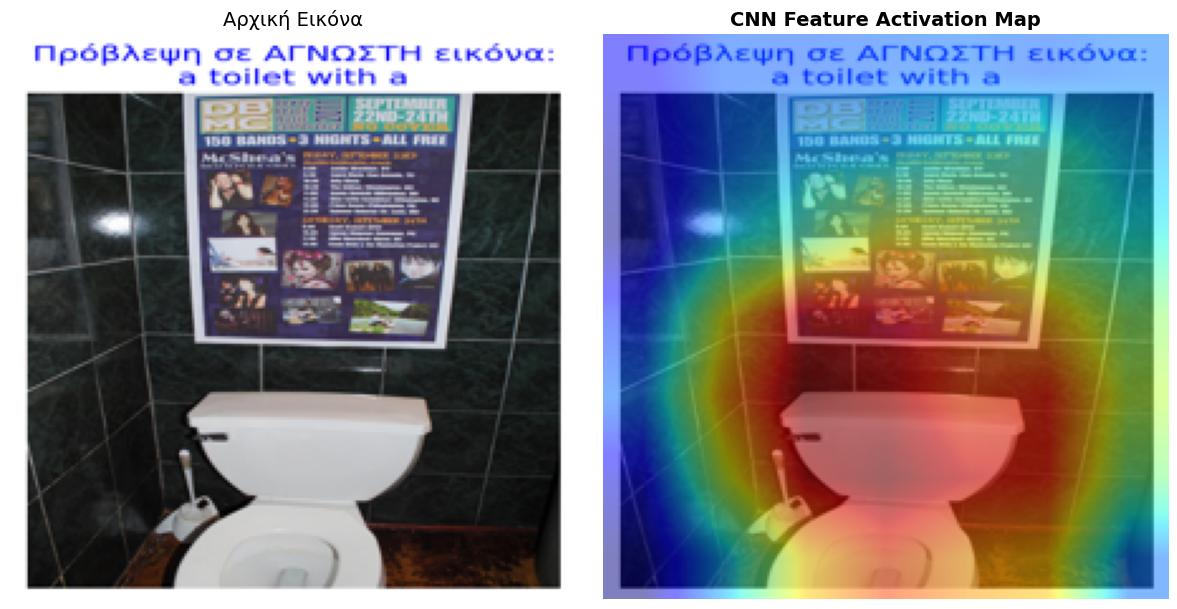

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import torchvision.transforms as transforms
import torch
import torch.nn.functional as F
from google.colab import files
import io
import numpy as np

def visualize_cnn_attention(model, image_bytes):
    # Μετασχηματισμός
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])

    # Αρχική εικόνα (για εμφάνιση στο background)
    original_image = Image.open(io.BytesIO(image_bytes)).convert("RGB")
    original_image = original_image.resize((224, 224))
    image_tensor = transform(original_image).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        # Προσοχή: Εδώ ΠΑΡΑΚΑΜΠΤΟΥΜΕ την pool() για να πάρουμε το "πλέγμα" 7x7 του ResNet
        features_spatial = model.encoder.resnet(image_tensor) # shape: [1, 2048, 7, 7]

        # Υπολογίζουμε τον μέσο όρο των 2048 φίλτρων (Πού εστίασε το CNN συνολικά;)
        heatmap = features_spatial.mean(dim=1, keepdim=True) # shape: [1, 1, 7, 7]

        # Μεγεθύνουμε το 7x7 σε 224x224 για να ταιριάζει με την εικόνα μας
        heatmap_resized = F.interpolate(heatmap, size=(224, 224), mode='bilinear', align_corners=False)
        heatmap_numpy = heatmap_resized.squeeze().cpu().numpy()

        # Κανονικοποίηση μεταξύ 0 και 1 (για να γίνει σωστό το χρώμα)
        heatmap_numpy = np.maximum(heatmap_numpy, 0) # Σβήνουμε τις αρνητικές τιμές
        heatmap_numpy = (heatmap_numpy - heatmap_numpy.min()) / (heatmap_numpy.max() - heatmap_numpy.min())

    # Εμφάνιση: Αριστερά η αρχική, Δεξιά το Heatmap!
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))

    axes[0].imshow(original_image)
    axes[0].axis('off')
    axes[0].set_title('Αρχική Εικόνα', fontsize=14)

    axes[1].imshow(original_image)
    # Overlay του heatmap με χρώμα 'jet' (κρύο->μπλε, ζεστό->κόκκινο)
    im = axes[1].imshow(heatmap_numpy, cmap='jet', alpha=0.5)
    axes[1].axis('off')
    axes[1].set_title('CNN Feature Activation Map', fontsize=14, fontweight='bold')

    plt.tight_layout()
    plt.show()

print("\n" + "="*50)
print("ΑΝΑΛΥΣΗ ΟΡΑΣΗΣ CNN (HEATMAP)")
print("Ανεβάζω μία φωτογραφία:")
uploaded = files.upload()

if len(uploaded) > 0:
    image_name = list(uploaded.keys())[0]
    image_bytes = uploaded[image_name]
    visualize_cnn_attention(model, image_bytes)
else:
    print("\nΔεν ανέβασες κάποια εικόνα.")

# Βήμα 10: Ενοποιημένη Εκπαίδευση και CNN Fine-Tuning

Σε αυτή τη φάση εφαρμόζεται πιο οργανωμένη στρατηγική fine-tuning:

1. **Transfer Learning:** Χρησιμοποιούνται εκπαιδευμένα βάρη από προηγούμενο COCO checkpoint.
2. **Warm-up Phase:** Στις πρώτες εποχές το CNN παραμένει frozen και εκπαιδεύεται κυρίως ο Transformer Decoder.
3. **Dynamic Fine-Tuning:** Στη συνέχεια ξεκλειδώνεται μέρος του ResNet50, ώστε τα οπτικά χαρακτηριστικά να προσαρμοστούν καλύτερα στο captioning task.
4. **Differential Learning Rate:** Χρησιμοποιείται μικρότερο learning rate για το CNN και μεγαλύτερο για τον Transformer.
5. **Early Stopping και Checkpointing:** Αποθηκεύεται το καλύτερο μοντέλο και αποφεύγεται περιττή εκπαίδευση.

Σημείωση: Τα checkpoint paths αντιστοιχούν στο προσωπικό Google Drive όπου αποθηκεύτηκαν τα εκπαιδευμένα μοντέλα κατά την εκτέλεση στο Colab.

In [ ]:
import torch
import torch.optim as optim
import torch.nn as nn
import time

# 1. Κλάση EarlyStopping (Κλάση EarlyStopping)
class EarlyStopping:
    def __init__(self, patience=4, min_delta=0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = None
        self.early_stop = False

    def __call__(self, current_loss, model, path):
        if self.best_loss is None:
            self.best_loss = current_loss
            self.save_checkpoint(model, path)
        elif current_loss > self.best_loss - self.min_delta:
            self.counter += 1
            print(f'EarlyStopping: {self.counter}/{self.patience} εποχές χωρίς βελτίωση.')
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = current_loss
            self.save_checkpoint(model, path)
            self.counter = 0

    def save_checkpoint(self, model, path):
        torch.save(model.state_dict(), path)
        print('Βελτίωση loss: το μοντέλο αποθηκεύτηκε στο Drive.')

# 2. Αρχικοποίηση Συστήματος
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Έναρξη πειράματος fine-tuning σε {device}...")

vocab_size = len(vocab.itos)
model = CNNtoTransformer(embed_size=256, vocab_size=vocab_size).to(device)

# Φόρτωση αρχικού checkpoint για να συνεχιστεί η εκπαίδευση.
model.load_state_dict(torch.load('/content/drive/MyDrive/coco_smart_model.pth', map_location=device))

# 3. Ρυθμίσεις Εκπαίδευσης
num_epochs = 30
fine_tune_at = 4  # Ξεκλειδώνει στην 4η εποχή
learning_rate = 3e-4

# Κλειδώνουμε το CNN για τις 3 πρώτες εποχές (Warm-up Transformer)
for param in model.encoder.resnet.parameters():
    param.requires_grad = False

optimizer = optim.Adam(model.decoder.parameters(), lr=learning_rate)
criterion = nn.CrossEntropyLoss(ignore_index=vocab.stoi["<PAD>"])

early_stopping = EarlyStopping(patience=4)
save_path = '/content/drive/MyDrive/coco_master_finetuned.pth'

# 4. Κύριο training loop
for epoch in range(1, num_epochs + 1):
    start_time = time.time()

    # --- Δυναμικό Fine-Tuning ---
    if epoch == fine_tune_at:
        print("\nΞΕΚΛΕΙΔΩΜΑ CNN: Ενεργοποίηση Fine-Tuning για το ResNet50...")
        for param in model.encoder.resnet.parameters():
            param.requires_grad = True

        # Προσθέτουμε το CNN στον optimizer με πολύ μικρό LR (1e-5) για σταθερότητα
        optimizer = optim.Adam([
            {'params': model.decoder.parameters(), 'lr': 1e-4},
            {'params': model.encoder.resnet.parameters(), 'lr': 1e-5}
        ])

    model.train()
    epoch_loss = 0

    print(f"\n--- Εποχή [{epoch}/{num_epochs}] ---")
    for idx, (imgs, captions) in enumerate(dataloader): # Χρησιμοποιούμε το σωστό dataloader!
        imgs, captions = imgs.to(device), captions.to(device)

        # Ευθυγράμμιση διαστάσεων
        if captions.shape[0] != imgs.shape[0]:
            captions = captions.transpose(0, 1)

        optimizer.zero_grad()
        outputs = model(imgs, captions[:, :-1])
        loss = criterion(outputs.reshape(-1, outputs.shape[-1]), captions[:, 1:].reshape(-1))

        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

        # Εκτύπωση προόδου κάθε 100 batches
        if (idx + 1) % 100 == 0:
            print(f"   Batch {idx+1}/{len(dataloader)} | Τρέχον Loss: {loss.item():.4f}")

    avg_loss = epoch_loss / len(dataloader)
    epoch_time = (time.time() - start_time) / 60

    print(f"Τέλος Εποχής {epoch} | Μέσο Loss: {avg_loss:.4f} | Χρόνος: {epoch_time:.2f} λεπτά")

    # Έλεγχος Early Stopping
    early_stopping(avg_loss, model, save_path)

    if early_stopping.early_stop:
        print("\nΤο Early Stopping ενεργοποιήθηκε και η εκπαίδευση τερματίστηκε πρόωρα.")
        break

print("\nΗ εκπαίδευση ολοκληρώθηκε. Το fine-tuned checkpoint αποθηκεύτηκε στο Google Drive.")

# Βήμα 11: Φόρτωση Fine-Tuned Μοντέλου

Φορτώνεται το μοντέλο που προέκυψε μετά το fine-tuning στο MS COCO.  
Το μοντέλο τίθεται σε κατάσταση αξιολόγησης (`eval()`), ώστε να χρησιμοποιηθεί για inference.


In [ ]:
import torch

# 1. Ορισμός συσκευής
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 2. Αρχικοποίηση της αρχιτεκτονικής
vocab_size = len(vocab.itos)
model = CNNtoTransformer(embed_size=256, vocab_size=vocab_size).to(device)

# 3. Φόρτωση των εκπαιδευμένων βαρών (του μοντέλου που έφτασε στο Loss: 1.8162)
model_path = '/content/drive/MyDrive/coco_master_finetuned.pth'
model.load_state_dict(torch.load(model_path, map_location=device))

# 4. Ρύθμιση σε λειτουργία αξιολόγησης (απαραίτητο για το inference)
model.eval()

print("Το εκπαιδευμένο μοντέλο φορτώθηκε από το Drive.")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 201MB/s]


Το εκπαιδευμένο μοντέλο φορτώθηκε από το Drive.


# Βήμα 12: Καμπύλη Loss για Dynamic Fine-Tuning

Η καμπύλη παρουσιάζει την εξέλιξη του training loss κατά τη διάρκεια του extended fine-tuning.  
Η πτώση του loss μετά το unfreezing του CNN δείχνει ότι το οπτικό υποσύστημα προσαρμόζεται στα δεδομένα του MS COCO.


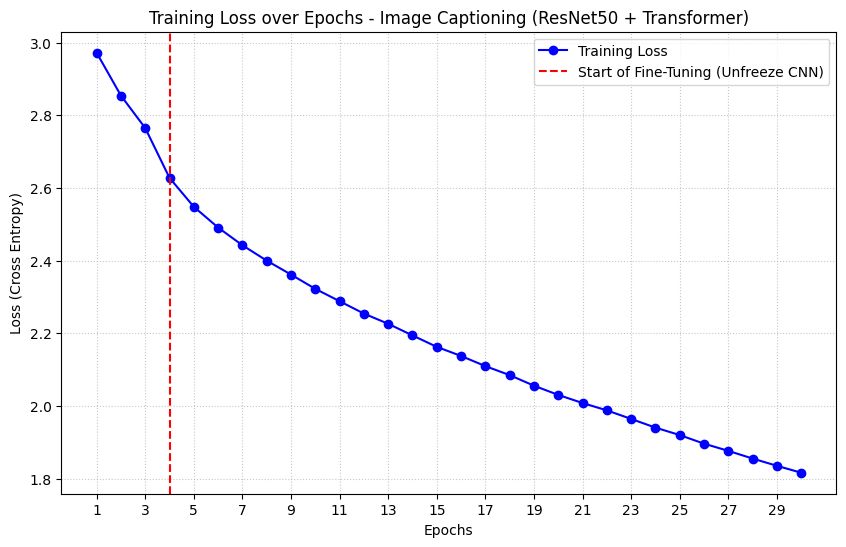

In [ ]:
import matplotlib.pyplot as plt

# Epochs και καταγεγραμμένες τιμές loss από το dynamic fine-tuning
epochs = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15,
          16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30]

# Καταγεγραμμένες τιμές loss από το dynamic fine-tuning.
loss_values = [2.9724, 2.8543, 2.7651, 2.6279, 2.5483, 2.4911, 2.4424, 2.4001, 2.3617, 2.3224,
               2.2884, 2.2543, 2.2262, 2.1942, 2.1627, 2.1376, 2.1097, 2.0849, 2.0558, 2.0304,
               2.0081, 1.9879, 1.9643, 1.9404, 1.9199, 1.8962, 1.8764, 1.8552, 1.8353, 1.8162]

plt.figure(figsize=(10, 6))

# Σχεδιασμός της καμπύλης
plt.plot(epochs, loss_values, marker='o', linestyle='-', color='b', label='Training Loss')

# Επισήμανση του σημείου έναρξης του Fine-Tuning
plt.axvline(x=4, color='r', linestyle='--', label='Start of Fine-Tuning (Unfreeze CNN)')

# Διαμόρφωση του γραφήματος
plt.title('Training Loss over Epochs - Image Captioning (ResNet50 + Transformer)')
plt.xlabel('Epochs')
plt.ylabel('Loss (Cross Entropy)')
plt.xticks(epochs[::2]) # Εμφάνιση κάθε δεύτερης εποχής στον άξονα x
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend()

# Αποθήκευση και εμφάνιση
plt.savefig('learning_curve.png', dpi=300)
plt.show()

# Βήμα 13: Σύνδεση του MS COCO Notebook με την Τελική Αναφορά

Το συγκεκριμένο notebook λειτουργεί ως συμπληρωματικό πείραμα γενίκευσης.  

**Cross-Dataset Validation και Ανάλυση Dataset Bias**

Η βασική ιδέα είναι ότι το αρχικό μοντέλο στο Flickr8k εμφάνισε bias προς εξωτερικές σκηνές και επαναλαμβανόμενα μοτίβα, όπως σκύλοι, γρασίδι και δράση.  
Με τη χρήση του MS COCO εξετάστηκε αν η ίδια αρχιτεκτονική μπορεί να προσαρμοστεί σε πιο πλούσιες σκηνές, όπως εσωτερικοί χώροι, αντικείμενα καθημερινότητας και πιο σύνθετες εικόνες.

Συνοπτικά, αυτό το δεύτερο dataset δείχνει:
- ότι η αρχιτεκτονική CNN + Transformer είναι επαναχρησιμοποιήσιμη,
- ότι το dataset επηρεάζει έντονα τη συμπεριφορά του μοντέλου,
- ότι το fine-tuning του CNN Encoder μπορεί να βελτιώσει την προσαρμογή στα νέα δεδομένα,
- ότι τα qualitative examples είναι απαραίτητα για να εξηγηθούν αποτυχίες που δεν φαίνονται μόνο από το loss.


# Βήμα 14: Πρόσθετο Πείραμα MS COCO - Greedy vs Beam Search

Σε αυτό το πείραμα δεν γίνεται νέα εκπαίδευση. Χρησιμοποιείται το ήδη εκπαιδευμένο fine-tuned μοντέλο του MS COCO και συγκρίνονται διαφορετικές στρατηγικές παραγωγής λεζάντας:

- Greedy Search
- Beam Search με `k=3`
- Beam Search με `k=5`

Ο στόχος είναι να εξεταστεί αν η στρατηγική αποκωδικοποίησης επηρεάζει την ποιότητα των παραγόμενων captions στο δεύτερο dataset.


In [ ]:
import os
import random
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from PIL import Image
from collections import defaultdict, Counter
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction

# Ρυθμίσεις πειράματος
NUM_EVAL_IMAGES = 50
RANDOM_SEED = 42
MAX_LENGTH = 30
coco_images_dir = "/content/coco_images/val2014/"

random.seed(RANDOM_SEED)

# Κοινό transform για inference
eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

def normalize_caption_text(text):
    """Απλός καθαρισμός caption για BLEU και length/repetition analysis."""
    text = text.lower().strip()
    text = text.replace(".", "").replace(",", "").replace(";", "").replace(":", "")
    text = text.replace("!", "").replace("?", "").replace('"', "")
    return text.split()

def clean_generated_tokens(indices, vocab):
    """Μετατροπή indices σε λέξεις και αφαίρεση ειδικών tokens."""
    special = {"<SOS>", "<EOS>", "<PAD>", "<UNK>"}
    words = [vocab.itos.get(idx, "<UNK>") for idx in indices]
    words = [w for w in words if w not in special]
    return words

def load_image_tensor_from_path(image_path):
    image = Image.open(image_path).convert("RGB")
    image_tensor = eval_transform(image).unsqueeze(0).to(device)
    return image, image_tensor

def generate_caption_greedy_path(model, image_path, vocab, max_length=30):
    """Greedy Search: σε κάθε βήμα επιλέγεται η πιθανότερη επόμενη λέξη."""
    model.eval()
    _, image_tensor = load_image_tensor_from_path(image_path)

    with torch.no_grad():
        features = model.encoder(image_tensor)
        seq = [vocab.stoi["<SOS>"]]
        eos_hit = False

        for _ in range(max_length):
            seq_tensor = torch.tensor(seq).unsqueeze(0).to(device)
            outputs = model.decoder(features, seq_tensor)
            next_idx = outputs[:, -1, :].argmax(dim=-1).item()
            seq.append(next_idx)

            if next_idx == vocab.stoi["<EOS>"]:
                eos_hit = True
                break

    words = clean_generated_tokens(seq, vocab)
    return " ".join(words), words, eos_hit

def generate_caption_beam_path(model, image_path, vocab, beam_width=3, max_length=30):
    """Beam Search: κρατά τις k καλύτερες υποψήφιες ακολουθίες σε κάθε βήμα."""
    model.eval()
    _, image_tensor = load_image_tensor_from_path(image_path)

    with torch.no_grad():
        features = model.encoder(image_tensor)
        beams = [(0.0, [vocab.stoi["<SOS>"]], False)]  # score, sequence, eos_hit

        for _ in range(max_length):
            new_beams = []

            for score, seq, eos_hit in beams:
                if seq[-1] == vocab.stoi["<EOS>"]:
                    new_beams.append((score, seq, True))
                    continue

                seq_tensor = torch.tensor(seq).unsqueeze(0).to(device)
                outputs = model.decoder(features, seq_tensor)
                log_probs = F.log_softmax(outputs[:, -1, :], dim=-1)
                top_probs, top_indices = log_probs.topk(beam_width)

                for i in range(beam_width):
                    next_idx = top_indices[0, i].item()
                    next_score = score + top_probs[0, i].item()
                    next_seq = seq + [next_idx]
                    new_beams.append((next_score, next_seq, next_idx == vocab.stoi["<EOS>"]))

            beams = sorted(new_beams, key=lambda x: x[0], reverse=True)[:beam_width]

            if all(seq[-1] == vocab.stoi["<EOS>"] for _, seq, _ in beams):
                break

    best_score, best_seq, eos_hit = beams[0]
    words = clean_generated_tokens(best_seq, vocab)
    return " ".join(words), words, eos_hit

# Δημιουργία references ανά εικόνα από ΟΛΑ τα annotations του COCO
references_by_file = defaultdict(list)
for ann in coco_data["annotations"]:
    file_name = images_dict[ann["image_id"]]
    references_by_file[file_name].append(normalize_caption_text(ann["caption"]))

# Οι πρώτες 15.000 εγγραφές χρησιμοποιήθηκαν για training subset.
# Επιλέγουμε εικόνες που δεν ανήκουν σε αυτό το subset, ώστε η αξιολόγηση να είναι πιο δίκαιη.
training_files = set([file_name for file_name, _ in coco_captions])
candidate_files = [
    file_name for file_name in references_by_file.keys()
    if file_name not in training_files
    and os.path.exists(os.path.join(coco_images_dir, file_name))
]

eval_files = random.sample(candidate_files, min(NUM_EVAL_IMAGES, len(candidate_files)))
print(f"Αριθμός εικόνων αξιολόγησης: {len(eval_files)}")

methods = {
    "Greedy": lambda path: generate_caption_greedy_path(model, path, vocab, max_length=MAX_LENGTH),
    "Beam k=3": lambda path: generate_caption_beam_path(model, path, vocab, beam_width=3, max_length=MAX_LENGTH),
    "Beam k=5": lambda path: generate_caption_beam_path(model, path, vocab, beam_width=5, max_length=MAX_LENGTH),
}

all_results = []
summary_results = []

for method_name, generator in methods.items():
    hypotheses = []
    references = []
    eos_hits = []
    generated_lengths = []

    for file_name in eval_files:
        image_path = os.path.join(coco_images_dir, file_name)
        caption, tokens, eos_hit = generator(image_path)

        hypotheses.append(tokens)
        references.append(references_by_file[file_name])
        eos_hits.append(eos_hit)
        generated_lengths.append(len(tokens))

        all_results.append({
            "image": file_name,
            "method": method_name,
            "prediction": caption,
            "length": len(tokens),
            "eos_hit": eos_hit,
            "reference_1": " ".join(references_by_file[file_name][0]),
        })

    smoothie = SmoothingFunction().method1
    bleu1 = corpus_bleu(references, hypotheses, weights=(1, 0, 0, 0), smoothing_function=smoothie)
    bleu2 = corpus_bleu(references, hypotheses, weights=(0.5, 0.5, 0, 0), smoothing_function=smoothie)

    summary_results.append({
        "Method": method_name,
        "BLEU-1 (%)": round(bleu1 * 100, 2),
        "BLEU-2 (%)": round(bleu2 * 100, 2),
        "Average caption length": round(float(np.mean(generated_lengths)), 2),
        "EOS hit rate (%)": round(float(np.mean(eos_hits) * 100), 2),
    })

results_df = pd.DataFrame(all_results)
metrics_df = pd.DataFrame(summary_results)

results_df.to_csv("mscoco_greedy_beam_results.csv", index=False)
metrics_df.to_csv("mscoco_greedy_beam_metrics.csv", index=False)

print("Συγκεντρωτικά αποτελέσματα Greedy vs Beam:")
display(metrics_df)

print("\nΑποθηκεύτηκαν τα αρχεία:")
print("- mscoco_greedy_beam_results.csv")
print("- mscoco_greedy_beam_metrics.csv")

# Προβολή μερικών παραδειγμάτων
display(results_df.head(9))


Αριθμός εικόνων αξιολόγησης: 50
Συγκεντρωτικά αποτελέσματα Greedy vs Beam:


,Method,BLEU-1 (%),BLEU-2 (%),Average caption length,EOS hit rate (%)
0,Greedy,54.08,36.68,8.70,100.0
1,Beam k=3,57.30,38.56,9.08,100.0
2,Beam k=5,56.52,38.42,9.16,100.0



Αποθηκεύτηκαν τα αρχεία:
- mscoco_greedy_beam_results.csv
- mscoco_greedy_beam_metrics.csv


,image,method,prediction,length,eos_hit,reference_1
0,COCO_val2014_000000082678.jpg,Greedy,a white toilet sitting in front of a building ...,13,True,a cement bench near a railing that overlooks a...
1,COCO_val2014_000000448795.jpg,Greedy,a bathroom with a toilet and a sink and a mirror,11,True,there is a table with chairs and a stove in th...
2,COCO_val2014_000000122120.jpg,Greedy,a man riding a skateboard on a street.,8,True,a young man on a skateboard doing tricks
3,COCO_val2014_000000197616.jpg,Greedy,a brown teddy bear sitting on top of a desk.,10,True,stuffed teddy bear next to a laptop computer
4,COCO_val2014_000000492992.jpg,Greedy,a giraffe standing next to a,6,True,bird sits atop cattle on snow covered field
5,COCO_val2014_000000170784.jpg,Greedy,a bus parked in front of a building.,8,True,a red double decker bus driving past a tall bu...
6,COCO_val2014_000000189885.jpg,Greedy,a of sheep graze on a road.,7,True,a herd of sheep walking down a rural country road
7,COCO_val2014_000000490022.jpg,Greedy,a group of people sitting around a table eatin...,10,True,two kids on a couch playing video games
8,COCO_val2014_000000205247.jpg,Greedy,a bus driving down a road next to a,9,True,a long white red and blue bus driving down a s...


# Βήμα 15: Πρόσθετο Πείραμα MS COCO - Ανάλυση Μήκους και Επαναλήψεων

Σε αυτό το πείραμα αναλύεται η συμπεριφορά των διαφορετικών decoding methods.  
Δεν κοιτάμε μόνο BLEU, αλλά και πιο πρακτικά χαρακτηριστικά των captions:

- μέσο μήκος λεζάντας,
- πόσο συχνά το μοντέλο σταματά με `<EOS>`,
- πόσο συχνά εμφανίζονται επαναλήψεις λέξεων,
- παραδείγματα επιτυχιών και αποτυχιών.

Αυτό βοηθά να φανεί αν μια μέθοδος παράγει πιο φυσικές ή πιο επαναλαμβανόμενες λεζάντες.


In [ ]:
# Ανάλυση επαναλήψεων και μήκους για τα captions που δημιουργήθηκαν στο προηγούμενο κελί

STOPWORDS = {
    "a", "an", "the", "and", "or", "of", "in", "on", "at", "to", "with",
    "is", "are", "was", "were", "this", "that"
}

def has_repeated_content_word(text):
    tokens = normalize_caption_text(text)
    content_tokens = [t for t in tokens if t not in STOPWORDS]
    counts = Counter(content_tokens)
    return any(count > 1 for count in counts.values())

def has_repeated_bigram(text):
    tokens = normalize_caption_text(text)
    bigrams = list(zip(tokens, tokens[1:]))
    counts = Counter(bigrams)
    return any(count > 1 for count in counts.values())

summary_rows = []

for method_name, group in results_df.groupby("method"):
    avg_len = group["length"].mean()
    eos_rate = group["eos_hit"].mean() * 100
    short_rate = (group["length"] <= 4).mean() * 100
    content_repeat_rate = group["prediction"].apply(has_repeated_content_word).mean() * 100
    bigram_repeat_rate = group["prediction"].apply(has_repeated_bigram).mean() * 100

    summary_rows.append({
        "Method": method_name,
        "Average caption length": round(avg_len, 2),
        "EOS hit rate (%)": round(eos_rate, 2),
        "Very short captions (%)": round(short_rate, 2),
        "Repeated content word (%)": round(content_repeat_rate, 2),
        "Repeated bigram (%)": round(bigram_repeat_rate, 2),
    })

analysis_df = pd.DataFrame(summary_rows)
analysis_df.to_csv("mscoco_length_repetition_analysis.csv", index=False)

print("Συγκεντρωτική ανάλυση μήκους και επαναλήψεων:")
display(analysis_df)

print("\nΑποθηκεύτηκε αρχείο: mscoco_length_repetition_analysis.csv")

# Παραδείγματα πιθανών επαναλήψεων για ποιοτική ανάλυση
repetition_examples = results_df[
    results_df["prediction"].apply(has_repeated_content_word)
].head(10)

print("\nΠαραδείγματα captions με πιθανή επανάληψη σημαντικών λέξεων:")
display(repetition_examples[["image", "method", "prediction", "reference_1", "length", "eos_hit"]])

# Προαιρετική σύγκριση των ίδιων εικόνων για όλες τις μεθόδους
sample_images = eval_files[:5]
comparison_rows = []

for image_name in sample_images:
    rows = results_df[results_df["image"] == image_name]
    for _, row in rows.iterrows():
        comparison_rows.append({
            "Image": image_name,
            "Method": row["method"],
            "Prediction": row["prediction"],
            "Reference": row["reference_1"],
        })

comparison_df = pd.DataFrame(comparison_rows)
print("\nΣύγκριση Greedy / Beam στις ίδιες εικόνες:")
display(comparison_df)


Συγκεντρωτική ανάλυση μήκους και επαναλήψεων:


,Method,Average caption length,EOS hit rate (%),Very short captions (%),Repeated content word (%),Repeated bigram (%)
0,Beam k=3,9.08,100.0,0.0,6.0,6.0
1,Beam k=5,9.16,100.0,0.0,4.0,4.0
2,Greedy,8.70,100.0,4.0,6.0,8.0



Αποθηκεύτηκε αρχείο: mscoco_length_repetition_analysis.csv

Παραδείγματα captions με πιθανή επανάληψη σημαντικών λέξεων:


,image,method,prediction,reference_1,length,eos_hit
12,COCO_val2014_000000042137.jpg,Greedy,a city bus traveling down a city street.,a public transit bus on a city street,8,True
19,COCO_val2014_000000563424.jpg,Greedy,a man wearing a hat and a hat,a little boy with a hat holding a bat,8,True
42,COCO_val2014_000000436138.jpg,Greedy,a wooden bench sitting next to a green wall wi...,a small house with a wooden door and a wooden ...,12,True
62,COCO_val2014_000000042137.jpg,Beam k=3,a city bus traveling down a city street.,a public transit bus on a city street,8,True
69,COCO_val2014_000000563424.jpg,Beam k=3,a man wearing a hat and a hat holds a,a little boy with a hat holding a bat,10,True
82,COCO_val2014_000000025747.jpg,Beam k=3,a train traveling down a road next to a train ...,a train is moving along train tracks through t...,11,True
112,COCO_val2014_000000042137.jpg,Beam k=5,a city bus traveling down a city street.,a public transit bus on a city street,8,True
132,COCO_val2014_000000025747.jpg,Beam k=5,a train traveling down a road next to a train ...,a train is moving along train tracks through t...,11,True



Σύγκριση Greedy / Beam στις ίδιες εικόνες:


,Image,Method,Prediction,Reference
0,COCO_val2014_000000082678.jpg,Greedy,a white toilet sitting in front of a building ...,a cement bench near a railing that overlooks a...
1,COCO_val2014_000000082678.jpg,Beam k=3,a white toilet sitting on top of a wooden bench.,a cement bench near a railing that overlooks a...
2,COCO_val2014_000000082678.jpg,Beam k=5,a white toilet sitting on top of a wooden bench.,a cement bench near a railing that overlooks a...
3,COCO_val2014_000000448795.jpg,Greedy,a bathroom with a toilet and a sink and a mirror,there is a table with chairs and a stove in th...
4,COCO_val2014_000000448795.jpg,Beam k=3,a bathroom with a white toilet next to a sink.,there is a table with chairs and a stove in th...
5,COCO_val2014_000000448795.jpg,Beam k=5,a bathroom with a white toilet next to a sink.,there is a table with chairs and a stove in th...
6,COCO_val2014_000000122120.jpg,Greedy,a man riding a skateboard on a street.,a young man on a skateboard doing tricks
7,COCO_val2014_000000122120.jpg,Beam k=3,a man riding a skateboard down a street.,a young man on a skateboard doing tricks
8,COCO_val2014_000000122120.jpg,Beam k=5,a man riding a skateboard down a street.,a young man on a skateboard doing tricks
9,COCO_val2014_000000197616.jpg,Greedy,a brown teddy bear sitting on top of a desk.,stuffed teddy bear next to a laptop computer
